In [2]:
import cv2
import math
from ultralytics import YOLO

def calcular_angulo(A, B, C):
    # Cálculo matemático del ángulo entre tres puntos
    radianes = math.atan2(C[1] - B[1], C[0] - B[0]) - \
               math.atan2(A[1] - B[1], A[0] - B[0])
    angulo = abs(radianes * 180.0 / math.pi)
    if angulo > 180.0:
        angulo = 360 - angulo
    return angulo

# 1. Configuración de archivos
video_path = "sentadilla.mp4"
output_path = "resultado_con_angulo.mp4"

model = YOLO("yolo11n-pose.pt")
cap = cv2.VideoCapture(video_path)

# Propiedades del video
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

contador = 0
estado = "Arriba"

print("Procesando y dibujando ángulos... Espera un momento.")

try:
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        results = model(frame, verbose=False)

        for r in results:
            if r.keypoints is not None and len(r.keypoints.xy[0]) > 0:
                kpts = r.keypoints.xy[0] 
                
                try:
                    # Índices: Cadera=11, Rodilla=13, Tobillo=15
                    if len(kpts) > 15:
                        p11, p13, p15 = kpts[11], kpts[13], kpts[15]
                        
                        # Validar que los puntos clave sean visibles (coordenadas no sean 0)
                        if p11[0] > 0 and p13[0] > 0 and p15[0] > 0:
                            cadera = (int(p11[0]), int(p11[1]))
                            rodilla = (int(p13[0]), int(p13[1]))
                            tobillo = (int(p15[0]), int(p15[1]))

                            # Calcular ángulo actual
                            ang = calcular_angulo(cadera, rodilla, tobillo)

                            # Lógica de conteo
                            color_feedback = (0, 255, 0) # Verde por defecto
                            if ang > 160:
                                if estado == "Abajo":
                                    contador += 1
                                estado = "Arriba"
                            if ang < 90:
                                estado = "Abajo"
                                color_feedback = (0, 0, 255) # Rojo si está en profundidad

                            # --- DIBUJO PROFESIONAL ---
                            # Líneas de la pierna
                            cv2.line(frame, cadera, rodilla, (255, 255, 255), 3)
                            cv2.line(frame, rodilla, tobillo, (255, 255, 255), 3)
                            
                            # Círculos en articulaciones
                            cv2.circle(frame, rodilla, 8, color_feedback, -1)
                            cv2.circle(frame, cadera, 5, (255, 255, 255), -1)
                            cv2.circle(frame, tobillo, 5, (255, 255, 255), -1)

                            # Texto del ángulo (al lado de la rodilla)
                            cv2.putText(frame, f"{int(ang)} deg", (rodilla[0] + 15, rodilla[1]), 
                                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color_feedback, 2)
                            
                            # Texto del contador (esquina superior)
                            cv2.rectangle(frame, (20, 20), (250, 100), (0,0,0), -1) # Fondo negro para legibilidad
                            cv2.putText(frame, f"REPS: {contador}", (40, 75), 
                                        cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 4)
                except Exception:
                    pass

        out.write(frame)

    print(f"¡Proceso terminado! Revisa el archivo: {output_path}")

finally:
    cap.release()
    out.release()
    cv2.destroyAllWindows()

Procesando y dibujando ángulos... Espera un momento.
¡Proceso terminado! Revisa el archivo: resultado_con_angulo.mp4


#### El resultado es el siguiente:
Puedes ver como se cuentan las repeticiones y marca el ángulo

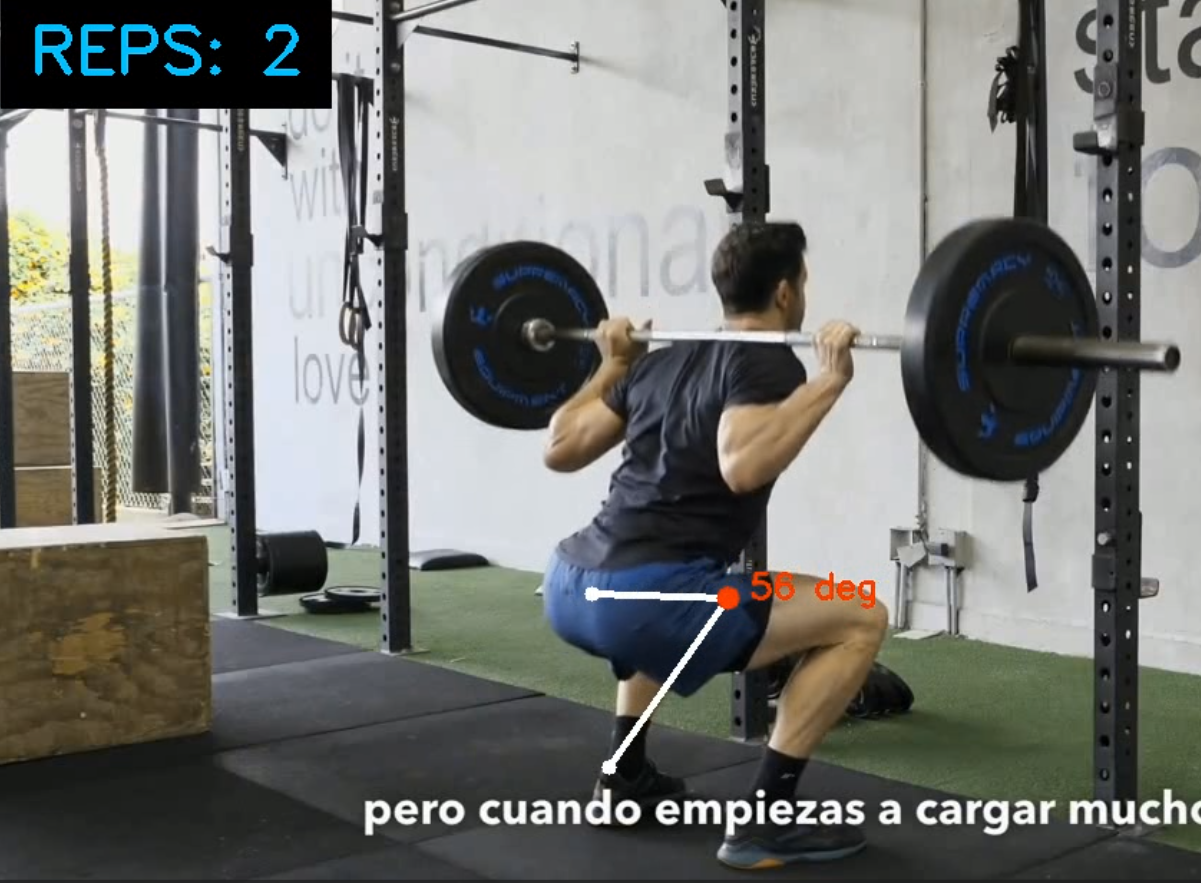